# A1

In [1]:
import pandas as pd
import numpy as np
from numpy.linalg import matrix_rank

df = pd.read_excel(r"C:\Users\ivysa\OneDrive\Desktop\College Projects\ML\Lab Session Data.xlsx", sheet_name="Purchase data")
X = df[["Candies (#)", "Mangoes (Kg)", "Milk Packets (#)"]].values      # dataframe indexing 
y = df["Payment (Rs)"].values

print("X =")
print(X)

print("\ny =")
print(y)

print("\nRank of feature matrix X:")
print(matrix_rank(X))

X_pinv = np.linalg.pinv(X)
c = np.dot(X_pinv, y)
print("\nCost of each product:")
print(c)
print("Candy: ", c[0])
print("Mango: ", c[1])
print("Milk Packet: ", c[2])

X =
[[20  6  2]
 [16  3  6]
 [27  6  2]
 [19  1  2]
 [24  4  2]
 [22  1  5]
 [15  4  2]
 [18  4  2]
 [21  1  4]
 [16  2  4]]

y =
[386 289 393 110 280 167 271 274 148 198]

Rank of feature matrix X:
3

Cost of each product:
[ 1. 55. 18.]
Candy:  0.9999999999999949
Mango:  55.000000000000014
Milk Packet:  18.0


# A2

In [2]:
import pandas as pd

df = pd.read_excel(r"C:\Users\ivysa\OneDrive\Desktop\College Projects\ML\Lab Session Data.xlsx", sheet_name="Purchase data")

df["Category"] = df["Payment (Rs)"].apply(
    lambda x: "Rich" if x > 200 else "Poor"
)

# Calculate purchase behaviour score
df["Score"] = (
    df["Candies (#)"] +
    df["Mangoes (Kg)"] +
    df["Milk Packets (#)"]
)

rich_mean = df[df["Category"] == "Rich"]["Score"].mean()
poor_mean = df[df["Category"] == "Poor"]["Score"].mean()

threshold = (rich_mean + poor_mean) / 2

print("Rich mean:", rich_mean)
print("Poor mean:", poor_mean)
print("Threshold:", threshold)

def classify(score):
    if score > threshold:
        return "Rich"
    else:
        return "Poor"

df["Predicted Category"] = df["Score"].apply(classify)

print(df[[
    "Customer",
    "Candies (#)",
    "Mangoes (Kg)",
    "Milk Packets (#)",
    "Payment (Rs)",
    "Category",
    "Predicted Category"
]])

Rich mean: 27.166666666666668
Poor mean: 24.5
Threshold: 25.833333333333336
  Customer  Candies (#)  Mangoes (Kg)  Milk Packets (#)  Payment (Rs)  \
0      C_1           20             6                 2           386   
1      C_2           16             3                 6           289   
2      C_3           27             6                 2           393   
3      C_4           19             1                 2           110   
4      C_5           24             4                 2           280   
5      C_6           22             1                 5           167   
6      C_7           15             4                 2           271   
7      C_8           18             4                 2           274   
8      C_9           21             1                 4           148   
9     C_10           16             2                 4           198   

  Category Predicted Category  
0     Rich               Rich  
1     Rich               Poor  
2     Rich              

# A3

Manual Mean : 1560.6634538152598
Built-in Mean: 1560.6634538152612
Manual Time for Mean: 8.371999865630642e-05
Built-in Time for Mean: 3.3639997127465904e-05

Manual Variance : 1.0
Built-in Variance: 58496.49239931613
Manual Time for Variance: 0.00031741000129841267
Built-in Time for Variance: 0.0001898300019092858

Sample Mean of Wednesday: 1550.7060000000001
Population mean: 1560.6634538152598

Sample Mean of April: 1698.9526315789474
Population mean: 1560.6634538152598

Probability of making loss: 0.4979919678714859
Probability of making profit on Wendesday: 0.42
Conditional probability of making a profit, given that today is Wednesday: 0.42


<function matplotlib.pyplot.show(close=None, block=None)>

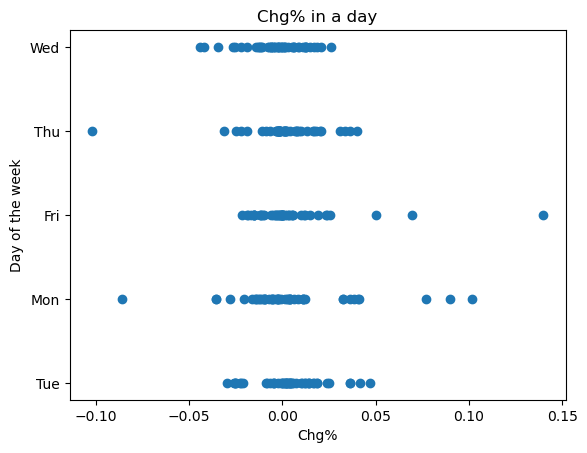

In [43]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

sp = (pd.read_excel(r"C:\Users\ivysa\Downloads\Lab Session Data.xlsx", sheet_name="IRCTC Stock Price"))

def stockPriceMean(column):
    sum = 0
    for price in column:
        sum += price
    avg = sum / len(column)
    return avg

def stockPriceVariance(column):
    mean = stockPriceMean(column)
    varSum = 0
    for price in column:
        varSum += (price - mean)**2
    variance = varSum / varSum
    return variance

def builtinMean(column):
    return np.mean(column)

def builtinVariance(data):
    return np.var(data)

def executionTime(function, column, runs = 10):
    total_time = 0
    for _ in range(runs):
        start = time.perf_counter()
        result = function(column)
        end = time.perf_counter()
        total_time += (end - start)
    avg_time = total_time /runs
    return result, avg_time

manual_result_mean, manual_time_mean = executionTime(stockPriceMean, sp["Price"].values)
builtin_result_mean, builtin_time_mean = executionTime(builtinMean, sp["Price"].values)

print("Manual Mean :", manual_result_mean)
print("Built-in Mean:", builtin_result_mean)

print("Manual Time for Mean:", manual_time_mean)
print("Built-in Time for Mean:", builtin_time_mean)
    
manual_result_variance, manual_time_variance = executionTime(stockPriceVariance, sp["Price"].values)
builtin_result_variance, builtin_time_variance = executionTime(builtinVariance, sp["Price"].values)

print("\nManual Variance :", manual_result_variance)
print("Built-in Variance:", builtin_result_variance)

print("Manual Time for Variance:", manual_time_variance)
print("Built-in Time for Variance:", builtin_time_variance)    

wednesdayPrice = sp[sp["Day"] == "Wed"]["Price"]
print("\nSample Mean of Wednesday:", wednesdayPrice.mean())
print("Population mean:", stockPriceMean(sp["Price"].values))

sp["Date"] = pd.to_datetime(sp["Date"])
AprPrices = sp[sp["Date"].dt.month == 4]["Price"]
print("\nSample Mean of April:", AprPrices.mean())
print("Population mean:", stockPriceMean(sp["Price"].values))

lossProb = (sp["Chg%"].apply(lambda x: x < 0).sum() / len(sp))
print("\nProbability of making loss:", lossProb)

profitProb_Wed = sp[sp["Day"] == "Wed"]["Chg%"]
profitProb = (profitProb_Wed.apply(lambda x: x > 0).sum() / len(profitProb_Wed))
print("Probability of making profit on Wendesday:", profitProb)

wednesday = sp[sp["Day"] == "Wed"]
profitWed = len(wednesday[wednesday["Chg%"] > 0])
totalWed = len(wednesday)
probability = profitWed / totalWed    #conditional probability   
print("Conditional probability of making a profit, given that today is Wednesday:", probability)

plt.scatter(sp["Chg%"].values, sp["Day"].values)
plt.title("Chg% in a day")
plt.xlabel("Chg%")
plt.ylabel("Day of the week")
plt.show

# A4

In [6]:
import pandas as pd
import numpy as np

df = pd.read_excel(r"C:\Users\ivysa\OneDrive\Desktop\College Projects\ML\Lab Session Data.xlsx", sheet_name="thyroid0387_UCI", na_values=["?"])

print("\n--- Attribute Type and Encoding Scheme ---")
for col in df.columns:
    if col == "Record ID":
        print(col, "-> Identifier -> No Encoding")
    elif col in ["age", "TSH", "T3", "TT4", "T4U", "FTI", "TBG"]:
        print(col, "-> Numeric -> No Encoding")
    elif col == "Condition":
        print(col, "-> Nominal -> One-Hot Encoding")
    else:
        print(col, "-> Nominal/Binary -> One-Hot Encoding")

numeric_cols = [
    "age", "TSH", "T3", "TT4",
    "T4U", "FTI", "TBG"
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
print("\n--- Numeric Range ---")
for col in numeric_cols:
    print(
        col,
        ":",
        df[col].min(),
        "to",
        df[col].max()
    )

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Mean and Variance ---")
result = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Variance": df[numeric_cols].var()
})
print(result)


--- Attribute Type and Encoding Scheme ---
Record ID -> Identifier -> No Encoding
age -> Numeric -> No Encoding
sex -> Nominal/Binary -> One-Hot Encoding
on thyroxine -> Nominal/Binary -> One-Hot Encoding
query on thyroxine -> Nominal/Binary -> One-Hot Encoding
on antithyroid medication -> Nominal/Binary -> One-Hot Encoding
sick -> Nominal/Binary -> One-Hot Encoding
pregnant -> Nominal/Binary -> One-Hot Encoding
thyroid surgery -> Nominal/Binary -> One-Hot Encoding
I131 treatment -> Nominal/Binary -> One-Hot Encoding
query hypothyroid -> Nominal/Binary -> One-Hot Encoding
query hyperthyroid -> Nominal/Binary -> One-Hot Encoding
lithium -> Nominal/Binary -> One-Hot Encoding
goitre -> Nominal/Binary -> One-Hot Encoding
tumor -> Nominal/Binary -> One-Hot Encoding
hypopituitary -> Nominal/Binary -> One-Hot Encoding
psych -> Nominal/Binary -> One-Hot Encoding
TSH measured -> Nominal/Binary -> One-Hot Encoding
TSH -> Numeric -> No Encoding
T3 measured -> Nominal/Binary -> One-Hot Encoding
T

# A5

In [10]:
import pandas as pd

df = pd.read_excel(
    r"C:\Users\ivysa\OneDrive\Desktop\College Projects\ML\Lab Session Data.xlsx",
    sheet_name="thyroid0387_UCI",
    na_values=["?"]
)

binary_cols = [
    "on thyroxine",
    "query on thyroxine",
    "on antithyroid medication",
    "sick",
    "pregnant",
    "thyroid surgery",
    "I131 treatment",
    "query hypothyroid",
    "query hyperthyroid",
    "lithium",
    "goitre",
    "tumor",
    "hypopituitary",
    "psych",
    "TSH measured",
    "T3 measured",
    "TT4 measured",
    "T4U measured",
    "FTI measured",
    "TBG measured"
]

v1 = df.loc[0, binary_cols]
v2 = df.loc[1, binary_cols]

v1 = v1.map({"t": 1, "f": 0})
v2 = v2.map({"t": 1, "f": 0})

print("First vector:")
print(v1)

print("\nSecond vector:")
print(v2)

f11 = ((v1 == 1) & (v2 == 1)).sum()
f10 = ((v1 == 1) & (v2 == 0)).sum()
f01 = ((v1 == 0) & (v2 == 1)).sum()
f00 = ((v1 == 0) & (v2 == 0)).sum()

print("\nf11 =", f11)
print("f10 =", f10)
print("f01 =", f01)
print("f00 =", f00)

JC = f11 / (f01 + f10 + f11)

SMC = (f11 + f00) / (f00 + f01 + f10 + f11)

print("\nJaccard Coefficient (JC):", JC)
print("Simple Matching Coefficient (SMC):", SMC)

First vector:
on thyroxine                 0
query on thyroxine           0
on antithyroid medication    0
sick                         0
pregnant                     0
thyroid surgery              0
I131 treatment               0
query hypothyroid            1
query hyperthyroid           0
lithium                      0
goitre                       0
tumor                        0
hypopituitary                0
psych                        0
TSH measured                 1
T3 measured                  0
TT4 measured                 0
T4U measured                 0
FTI measured                 0
TBG measured                 0
Name: 0, dtype: int64

Second vector:
on thyroxine                 0
query on thyroxine           0
on antithyroid medication    0
sick                         0
pregnant                     0
thyroid surgery              0
I131 treatment               0
query hypothyroid            0
query hyperthyroid           0
lithium                      0
goitre            

# A6

In [12]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

df = pd.read_excel(
    r"C:\Users\ivysa\OneDrive\Desktop\College Projects\ML\Lab Session Data.xlsx",
    sheet_name="thyroid0387_UCI",
    na_values=["?"]
)

numeric_cols = ["age", "TSH", "T3", "TT4", "T4U", "FTI", "TBG"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.drop(columns=["Record ID"])

df_encoded = pd.get_dummies(df, drop_first=False)

df_encoded = df_encoded.fillna(0)

v1 = df_encoded.iloc[0].values.reshape(1, -1)
v2 = df_encoded.iloc[1].values.reshape(1, -1)

cosine_sim = cosine_similarity(v1, v2)

print("Cosine Similarity:", cosine_sim[0][0])

Cosine Similarity: 0.22310981365067695


# A7

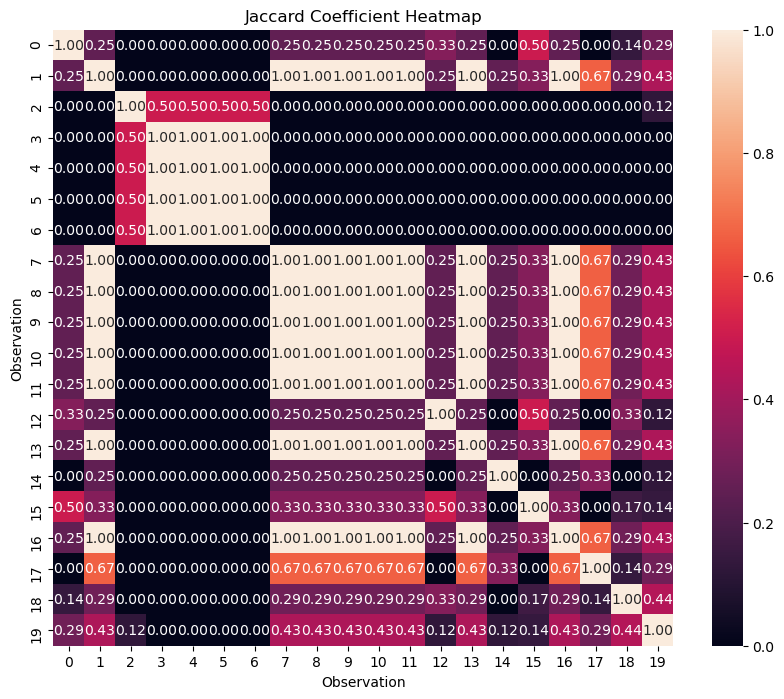

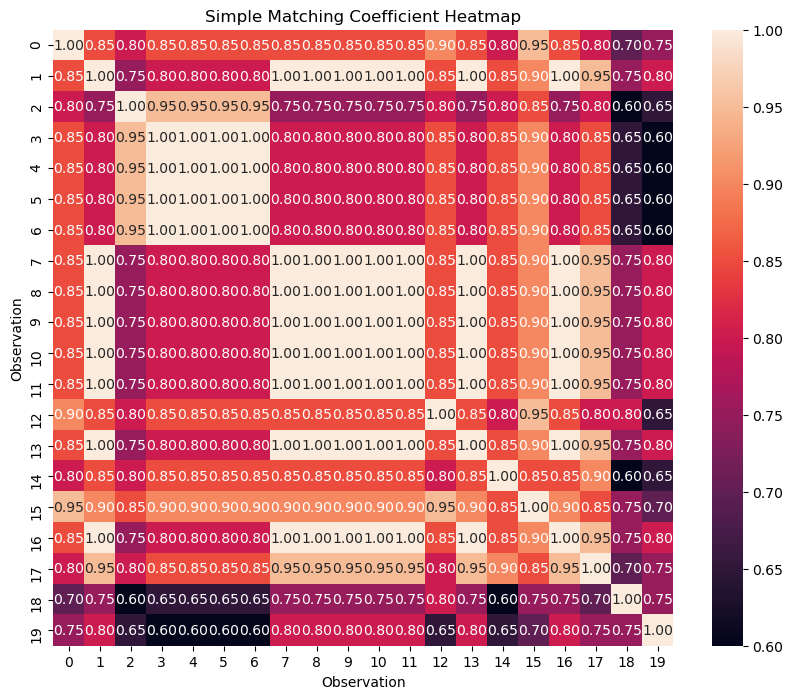

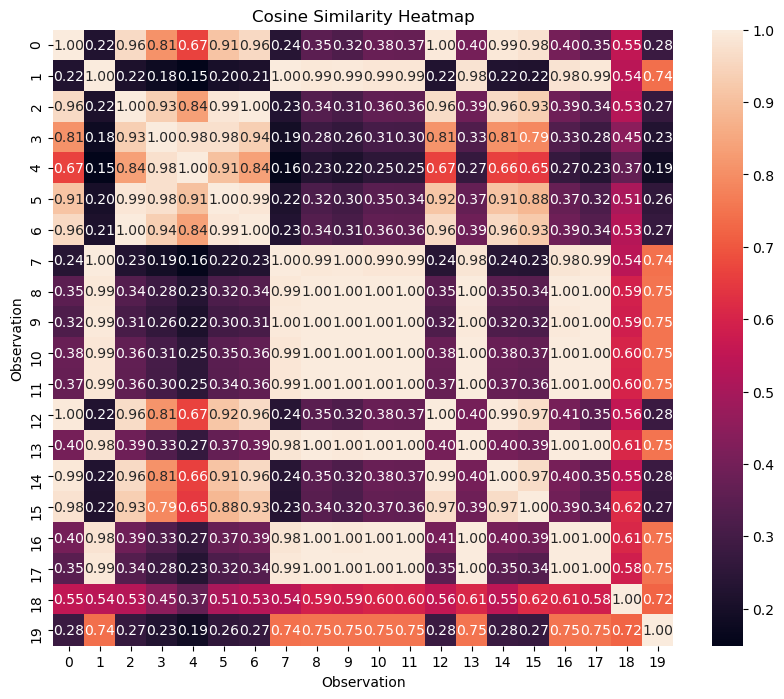

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

df = pd.read_excel(
    r"C:\Users\ivysa\OneDrive\Desktop\College Projects\ML\Lab Session Data.xlsx",
    sheet_name="thyroid0387_UCI",
    na_values=["?"]
)

binary_cols = [
    "on thyroxine",
    "query on thyroxine",
    "on antithyroid medication",
    "sick",
    "pregnant",
    "thyroid surgery",
    "I131 treatment",
    "query hypothyroid",
    "query hyperthyroid",
    "lithium",
    "goitre",
    "tumor",
    "hypopituitary",
    "psych",
    "TSH measured",
    "T3 measured",
    "TT4 measured",
    "T4U measured",
    "FTI measured",
    "TBG measured"
]

binary_data = df.loc[:19, binary_cols]

binary_data = binary_data.replace({"t": 1, "f": 0})

binary_data = binary_data.astype(float)
n = 20
JC = np.zeros((n, n))
SMC = np.zeros((n, n))
for i in range(n):
    for j in range(n):

        v1 = binary_data.iloc[i]
        v2 = binary_data.iloc[j]

        f11 = ((v1 == 1) & (v2 == 1)).sum()
        f10 = ((v1 == 1) & (v2 == 0)).sum()
        f01 = ((v1 == 0) & (v2 == 1)).sum()
        f00 = ((v1 == 0) & (v2 == 0)).sum()

        denominator = f01 + f10 + f11
        if denominator == 0:
            JC[i, j] = 0
        else:
            JC[i, j] = f11 / denominator
        SMC[i, j] = (f11 + f00) / (
            f00 + f01 + f10 + f11
        )

numeric_cols = [
    "age", "TSH", "T3", "TT4",
    "T4U", "FTI", "TBG"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df_cos = df.drop(columns=["Record ID"])

df_cos = pd.get_dummies(df_cos)

df_cos = df_cos.fillna(0)

first20 = df_cos.iloc[:20]

COS = cosine_similarity(first20)

plt.figure(figsize=(10, 8))
sns.heatmap(JC, annot=True, fmt=".2f")
plt.title("Jaccard Coefficient Heatmap")
plt.xlabel("Observation")
plt.ylabel("Observation")
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(SMC, annot=True, fmt=".2f")
plt.title("Simple Matching Coefficient Heatmap")
plt.xlabel("Observation")
plt.ylabel("Observation")
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(COS, annot=True, fmt=".2f")
plt.title("Cosine Similarity Heatmap")
plt.xlabel("Observation")
plt.ylabel("Observation")
plt.show()



# A8

In [17]:
import pandas as pd
import numpy as np

df = pd.read_excel(
    r"C:\Users\ivysa\OneDrive\Desktop\College Projects\ML\Lab Session Data.xlsx",
    sheet_name="thyroid0387_UCI",
    na_values=["?"]
)

numeric_cols = [
    "age", "TSH", "T3", "TT4",
    "T4U", "FTI", "TBG"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        mean = df[col].mean()
        std = df[col].std()
        lower = mean - 3 * std
        upper = mean + 3 * std
        outliers = df[
            (df[col] < lower) |
            (df[col] > upper)
        ]
        if len(outliers) == 0:
            # No outliers -> Mean
            df[col] = df[col].fillna(mean)
            print(col, "-> Mean used")
        else:
            # Outliers present -> Median
            median = df[col].median()
            df[col] = df[col].fillna(median)
            print(col, "-> Median used")

categorical_cols = df.select_dtypes(
    include="object"
).columns

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode = df[col].mode()[0]
        df[col] = df[col].fillna(mode)
        print(col, "-> Mode used")

print("\n--- Missing Values After Imputation ---")
print(df.isnull().sum())

TSH -> Median used
T3 -> Median used
TT4 -> Median used
T4U -> Median used
FTI -> Median used
TBG -> Median used
sex -> Mode used

--- Missing Values After Imputation ---
Record ID                    0
age                          0
sex                          0
on thyroxine                 0
query on thyroxine           0
on antithyroid medication    0
sick                         0
pregnant                     0
thyroid surgery              0
I131 treatment               0
query hypothyroid            0
query hyperthyroid           0
lithium                      0
goitre                       0
tumor                        0
hypopituitary                0
psych                        0
TSH measured                 0
TSH                          0
T3 measured                  0
T3                           0
TT4 measured                 0
TT4                          0
T4U measured                 0
T4U                          0
FTI measured                 0
FTI                    

# A9

In [18]:
import pandas as pd
import numpy as np

df = pd.read_excel(
    r"C:\Users\ivysa\OneDrive\Desktop\College Projects\ML\Lab Session Data.xlsx",
    sheet_name="thyroid0387_UCI",
    na_values=["?"]
)

numeric_cols = [
    "age",
    "TSH",
    "T3",
    "TT4",
    "T4U",
    "FTI",
    "TBG"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

df_scalar = df.copy()

for col in numeric_cols:
    minimum = np.min(df[col])
    maximum = np.max(df[col])

    df_scalar[col] = (
        (df[col] - minimum) /
        (maximum - minimum)
    )

df_zscore = df.copy()
for col in numeric_cols:
    mean = np.mean(df[col])
    std = np.std(df[col])
    df_zscore[col] = (
        (df[col] - mean) /
        std
    )

print("--- Original Numeric Data ---")
print(df[numeric_cols].head())

print("\n--- Scalar / Min-Max Normalized Data ---")
print(df_scalar[numeric_cols].head())

print("\n--- Z-Score Normalized Data ---")
print(df_zscore[numeric_cols].head())

print("\n--- Scalar Normalization Range ---")

for col in numeric_cols:
    print(
        col,
        ":",
        np.min(df_scalar[col]),
        "to",
        np.max(df_scalar[col])
    )

print("\n--- Z-Score Mean and Standard Deviation ---")

for col in numeric_cols:
    print(
        col,
        "Mean =",
        np.mean(df_zscore[col]),
        "Std =",
        np.std(df_zscore[col])
    )

--- Original Numeric Data ---
   age  TSH   T3    TT4   T4U    FTI   TBG
0   29  0.3  1.9  104.0  0.96  109.0  26.0
1   29  1.6  1.9  128.0  0.96  109.0  26.0
2   41  1.4  1.9  104.0  0.96  109.0  11.0
3   36  1.4  1.9  104.0  0.96  109.0  26.0
4   32  1.4  1.9  104.0  0.96  109.0  36.0

--- Scalar / Min-Max Normalized Data ---
        age       TSH        T3       TT4       T4U       FTI       TBG
0  0.000427  0.000557  0.103064  0.170569  0.365741  0.122328  0.129565
1  0.000427  0.003009  0.103064  0.210702  0.365741  0.122328  0.129565
2  0.000610  0.002632  0.103064  0.170569  0.365741  0.122328  0.054527
3  0.000534  0.002632  0.103064  0.170569  0.365741  0.122328  0.129565
4  0.000473  0.002632  0.103064  0.170569  0.365741  0.122328  0.179590

--- Z-Score Normalized Data ---
        age       TSH        T3       TT4       T4U      FTI       TBG
0 -0.037634 -0.197981 -0.067283 -0.122171 -0.076501 -0.10664 -0.035293
1 -0.037634 -0.141637 -0.067283  0.533224 -0.076501 -0.10664 -0